# HKH Glacial Lake Statistics with SRTM Elevation (2020 vs 2025)

This notebook:
1. **Downloads SRTM 30 m DEM tiles** for the HKH region (you provide the tile URLs from NASA Earthdata/USGS).
2. **Mosaics** the SRTM tiles into a single DEM for HKH.
3. **Computes mean elevation** for each glacial lake polygon (2020 & 2025) using the DEM.
4. **Recomputes all statistics** (Points 1 & 2): total area/number, size/elevation distributions, and 2020â†’2025 changes.

âš ï¸ **Important:**
- You must have a NASA Earthdata account and accept the SRTM data license.
- From Earthdata/USGS EarthExplorer, copy the download URLs of the SRTM tiles covering HKH and paste them into the `SRTM_TILE_URLS` list.
- This notebook assumes **SRTM 1 Arc-Second Global (~30 m)** GeoTIFF tiles.

Once configured, run all cells from top to bottom.

In [ ]:
# Optional: install required packages (uncomment and run if needed)
# %pip install geopandas rasterio rasterstats shapely
# If using conda, you may prefer: conda install -c conda-forge geopandas rasterio rasterstats shapely

In [1]:
# === Imports ===
import os
from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterstats import zonal_stats

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 50)

In [2]:
# === Configuration ===

# Paths to your lake shapefiles (update these)
LAKES_2020_SHP = r"D:\Thesis\glacial_lake_detection_thesis\outputs\thesis_results\statistics\inputs\hkh_lakes_2020.zip"   # <-- update
LAKES_2025_SHP = r"D:\Thesis\glacial_lake_detection_thesis\outputs\thesis_results\statistics\inputs\hkh_filtered_lakes_2025.zip"   # <-- update

# Output lake shapefiles with elevation
OUT_LAKES_2020_SHP = r"D:\Thesis\glacial_lake_detection_thesis\outputs\thesis_results\statistics\outputs\hkh_lakes_2020_with_elev.shp"
OUT_LAKES_2025_SHP = r"D:\Thesis\glacial_lake_detection_thesis\outputs\thesis_results\statistics\outputs\hkh_lakes_2025_with_elev.shp"

# Directory to store downloaded SRTM tiles and the mosaic DEM
SRTM_DOWNLOAD_DIR = Path("srtm_tiles")
SRTM_DOWNLOAD_DIR.mkdir(exist_ok=True)

SRTM_MOSAIC_PATH = Path(r"D:\Thesis\glacial_lake_detection_thesis\outputs\thesis_results\statistics\outputs\HKH_SRTM_30m_mosaic.tif")
SRTM_MOSAIC_PATH_CLIPPED = Path(r"D:\Thesis\glacial_lake_detection_thesis\outputs\thesis_results\statistics\outputs\HKH_SRTM_30m_clipped.tif")


# NASA Earthdata credentials (required for scripted downloads)
EARTHDATA_USER = "your_earthdata_username"   # <-- update
EARTHDATA_PASS = "your_earthdata_password"   # <-- update

# List of SRTM tile URLs (copy from Earthdata/USGS for tiles covering HKH)
# Example placeholder URLs â€“ REPLACE WITH REAL ONES
SRTM_TILE_URLS = [
    # "https://e4ftl01.cr.usgs.gov/SRTM/SRTMGL1.003/2000.02.11/N35E075.SRTMGL1.hgt.zip",
    # "https://e4ftl01.cr.usgs.gov/SRTM/SRTMGL1.003/2000.02.11/N35E076.SRTMGL1.hgt.zip",
]

# Area column name (kmÂ²)
AREA_COL = "area_km2"

# Elevation column name (mean lake elevation in meters)
LAKE_ELEV_COL = "elev_mean"

# Time period between inventories (years) â€“ used for APAC
DELTA_T_YEARS = 5.0  # 2020 â†’ 2025

# Equal-area CRS for area calculation (can be EPSG:6933 or a regional equal-area projection)
AREA_CRS = "EPSG:6933"

## 1. Download SRTM tiles from NASA Earthdata

This cell uses `requests` with basic auth to download each SRTM tile URL to `SRTM_DOWNLOAD_DIR`.

Steps:
1. Log in to [Earthdata](https://urs.earthdata.nasa.gov/).
2. Search for **SRTM 1 Arc-Second Global**.
3. Select the tiles covering HKH and generate download URLs.
4. Paste the URLs into `SRTM_TILE_URLS` in the configuration cell.
5. Run the cell below.

In [ ]:
import requests

def download_srtm_tiles(urls, out_dir: Path, user: str, password: str):
    if not urls:
        print("[WARN] SRTM_TILE_URLS is empty. Please add SRTM tile URLs and rerun.")
        return

    session = requests.Session()
    session.auth = (user, password)

    for url in urls:
        filename = out_dir / Path(url).name
        if filename.exists():
            print(f"[INFO] File already exists, skipping: {filename}")
            continue
        print(f"Downloading {url} â†’ {filename} ...")
        resp = session.get(url, stream=True)
        if resp.status_code != 200:
            print(f"[ERROR] Failed to download {url} (status {resp.status_code})")
            continue
        with open(filename, "wb") as f:
            for chunk in resp.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
        print(f"[OK] Saved {filename}")

download_srtm_tiles(SRTM_TILE_URLS, SRTM_DOWNLOAD_DIR, EARTHDATA_USER, EARTHDATA_PASS)

## 2. Unzip and mosaic SRTM tiles

- If you downloaded **.zip** files (SRTM .hgt or GeoTIFF inside), this cell will unzip them.
- Then we open all `.tif` files and mosaic them into a single HKH DEM (`HKH_SRTM_30m_mosaic.tif`).

In [3]:

tif_paths = list(SRTM_DOWNLOAD_DIR.glob("*.tif"))
print(f"Found {len(tif_paths)} GeoTIFF tiles.")

if not tif_paths:
    print("[WARN] No .tif files found in SRTM_DOWNLOAD_DIR. Check that your downloads are correct.")

Found 61 GeoTIFF tiles.


In [4]:
def mosaic_rasters(tif_paths, out_path: Path):
    if not tif_paths:
        raise ValueError("No input rasters provided for mosaic.")

    src_files = [rasterio.open(str(fp)) for fp in tif_paths]
    mosaic, out_transform = merge(src_files)

    profile = src_files[0].profile
    profile.update(
        {
            "height": mosaic.shape[1],
            "width": mosaic.shape[2],
            "transform": out_transform,
        }
    )

    print(f"Writing mosaic DEM to {out_path} ...")
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(mosaic)

    for src in src_files:
        src.close()

if tif_paths:
    mosaic_rasters(tif_paths, SRTM_MOSAIC_PATH)
else:
    print("[WARN] Skipping mosaic because no tiles were found.")

Writing mosaic DEM to outputs\HKH_SRTM_30m_mosaic.tif ...


## 3. Load lake shapefiles and compute area & elevation

We will:
1. Load 2020 & 2025 lake shapefiles.
2. Reproject them to an equal-area CRS and compute area (kmÂ²).
3. Use the SRTM mosaic to compute **mean elevation** per lake using zonal statistics.
4. Save updated shapefiles with an `elev_mean` column.

In [3]:
def load_lakes(path: str, area_crs: str = AREA_CRS, area_col: str = AREA_COL):
    gdf = gpd.read_file(path)
    if gdf.crs is None:
        raise ValueError(f"Input lakes file {path} has no CRS. Please define it before using this notebook.")
    gdf = gdf.to_crs(area_crs)
    gdf[area_col] = gdf.geometry.area / 1e6  # m^2 → km^2
    return gdf

print("Loading lake shapefiles...")
gdf_2020 = load_lakes(LAKES_2020_SHP)
gdf_2025 = load_lakes(LAKES_2025_SHP)

if "lake_id" not in gdf_2020.columns:
    gdf_2020["lake_id"] = [f"L2020_{i}" for i in range(len(gdf_2020))]
if "lake_id" not in gdf_2025.columns:
    gdf_2025["lake_id"] = [f"L2025_{i}" for i in range(len(gdf_2025))]

gdf_2020.head(), gdf_2025.head()

Loading lake shapefiles...


(   OBJECTID_1  Id  OBJECTID  Shape_Leng   Shape_Le_1     Shape_Area  \
 0           1   0         0         0.0  4734.655069  950522.097801   
 1           2   0         0         0.0   806.707326   34728.361094   
 2           3   0         0         0.0  1202.063357   19693.201851   
 3           4   0         0         0.0  2016.005430  206074.467866   
 4           5   0         0         0.0   568.308747   21374.534646   
 
                                             geometry  area_km2  lake_id  
 0  POLYGON ((7145501.544 4181453.039, 7145523.417...  0.951110  L2020_0  
 1  POLYGON ((7148332.396 4179863.607, 7148336.14 ...  0.034750  L2020_1  
 2  POLYGON ((7146879.823 4178379.858, 7146888.649...  0.019705  L2020_2  
 3  POLYGON ((7147288.347 4183940.532, 7147285.423...  0.206203  L2020_3  
 4  POLYGON ((7147463.778 4184054.799, 7147442.345...  0.021388  L2020_4  ,
                                           source_img      area_m2  lake_id  \
 0  20250902_060832_78_24da_3B_Visua

In [11]:
import rasterio
from rasterio.mask import mask

# 1. Read DEM CRS
with rasterio.open(SRTM_MOSAIC_PATH) as src:
    dem_crs = src.crs

# 2. Reproject lakes to DEM CRS
gdf_dem = gdf_2025.to_crs(dem_crs)

# 3. Create union geometry mask
hkh_geom = gdf_dem.unary_union

# 4. Clip DEM using the mask
with rasterio.open(SRTM_MOSAIC_PATH) as src:
    out_img, out_transform = mask(src, [hkh_geom], crop=True)
    out_meta = src.meta.copy()

# 5. Save clipped DEM
out_meta.update({
    "height": out_img.shape[1],
    "width": out_img.shape[2],
    "transform": out_transform
})

with rasterio.open(SRTM_MOSAIC_PATH_CLIPPED, "w", **out_meta) as dst:
    dst.write(out_img)

print("Clipped DEM saved as HKH_SRTM_30m_clipped.tif")


C:\Users\gg\AppData\Local\Temp\ipykernel_19984\2775786476.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hkh_geom = gdf_dem.unary_union


Clipped DEM saved as HKH_SRTM_30m_clipped.tif


In [4]:
import rasterio
import numpy as np

def add_centroid_elevation(gdf: gpd.GeoDataFrame,
                           dem_path: Path,
                           elev_col: str = LAKE_ELEV_COL):
    """
    Adds elevation by sampling the DEM at each lake's centroid.
    This avoids loading the whole DEM into memory like zonal_stats.
    """
    if not dem_path.exists():
        raise FileNotFoundError(f"DEM file not found: {dem_path}")

    print(f"Sampling DEM at lake centroids: {dem_path}")

    # Open DEM
    with rasterio.open(dem_path) as src:
        # Reproject lakes to DEM CRS for correct sampling
        gdf_dem = gdf.to_crs(src.crs)

        # Get centroid coordinates
        centroids = gdf_dem.geometry.centroid
        coords = [(pt.x, pt.y) for pt in centroids]

        # Sample DEM at those points
        samples = list(src.sample(coords))

    # Extract elevation values (assumes single band)
    elevs = [float(v[0]) if (v[0] is not None and not np.isnan(v[0])) else np.nan
             for v in samples]

    # Attach elevation to original GeoDataFrame (original CRS preserved)
    gdf[elev_col] = elevs
    return gdf

gdf_2020 = add_centroid_elevation(gdf_2020, SRTM_MOSAIC_PATH, elev_col=LAKE_ELEV_COL)
gdf_2025 = add_centroid_elevation(gdf_2025, SRTM_MOSAIC_PATH, elev_col=LAKE_ELEV_COL)

print("Saving updated lake shapefiles with elevation...")
gdf_2020.to_file(OUT_LAKES_2020_SHP)
gdf_2025.to_file(OUT_LAKES_2025_SHP)

gdf_2020[["lake_id", AREA_COL, LAKE_ELEV_COL]].head()

Sampling DEM at lake centroids: D:\Thesis\glacial_lake_detection_thesis\outputs\thesis_results\statistics\outputs\HKH_SRTM_30m_mosaic.tif


C:\Users\gg\AppData\Local\Temp\ipykernel_18856\1909338735.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf_dem.geometry.centroid


Sampling DEM at lake centroids: D:\Thesis\glacial_lake_detection_thesis\outputs\thesis_results\statistics\outputs\HKH_SRTM_30m_mosaic.tif


C:\Users\gg\AppData\Local\Temp\ipykernel_18856\1909338735.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf_dem.geometry.centroid


Saving updated lake shapefiles with elevation...


,lake_id,area_km2,elev_mean
0,L2020_0,0.951110,3681.0
1,L2020_1,0.034750,3663.0
2,L2020_2,0.019705,3656.0
3,L2020_3,0.206203,3680.0
4,L2020_4,0.021388,3689.0


## 4. Helper functions for statistics

Now that elevation is attached, we can compute all stats: totals, size classes, elevation bands, and 2020â†’2025 changes.

In [5]:
def make_size_classes(area_series: pd.Series):
    bins = [0, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, np.inf]
    labels = [
        "<0.01",
        "0.01-0.05",
        "0.05-0.1",
        "0.1-0.5",
        "0.5-1",
        "1-5",
        "5-10",
        ">10",
    ]
    return pd.cut(area_series, bins=bins, labels=labels, right=False, include_lowest=True)

def make_elev_bands(elev_series: pd.Series):
    bins = [3000, 3500, 4000, 4500, 5000, 5500, 6000, np.inf]
    labels = [
        "3000-3500",
        "3500-4000",
        "4000-4500",
        "4500-5000",
        "5000-5500",
        "5500-6000",
        ">6000",
    ]
    return pd.cut(elev_series, bins=bins, labels=labels, right=False)

def summarize_lakes(gdf: gpd.GeoDataFrame, name: str):
    total_n = len(gdf)
    total_area = gdf[AREA_COL].sum()
    print(f"=== {name} lake inventory ===")
    print(f"Number of lakes: {total_n}")
    print(f"Total area (kmÂ²): {total_area:.3f}\n")
    return {"N": total_n, "A_km2": total_area}

def size_distribution(gdf: gpd.GeoDataFrame, name: str):
    gdf = gdf.copy()
    gdf["size_class"] = make_size_classes(gdf[AREA_COL])
    grp = gdf.groupby("size_class")[AREA_COL].agg(["count", "sum"]).rename(columns={"count": "n", "sum": "area_km2"})
    grp["fraction_n"] = grp["n"] / grp["n"].sum()
    grp["fraction_area"] = grp["area_km2"] / grp["area_km2"].sum()
    print(f"=== {name} size distribution ===")
    display(grp)
    return grp

def elev_distribution(gdf: gpd.GeoDataFrame, name: str, elev_col: str = LAKE_ELEV_COL):
    if elev_col not in gdf.columns:
        print(f"[WARN] Elevation column '{elev_col}' not found. Skipping elevation distribution for {name}.")
        return None
    gdf = gdf.copy()
    gdf["elev_band"] = make_elev_bands(gdf[elev_col])
    grp = gdf.groupby("elev_band")[AREA_COL].agg(["count", "sum"]).rename(columns={"count": "n", "sum": "area_km2"})
    grp["fraction_n"] = grp["n"] / grp["n"].sum()
    grp["fraction_area"] = grp["area_km2"] / grp["area_km2"].sum()
    print(f"=== {name} elevation distribution ===")
    display(grp)
    return grp

## 5. Point 1 stats: Basic 2020 & 2025 inventory, size & elevation distributions

In [6]:
summary_2020 = summarize_lakes(gdf_2020, "2020")
summary_2025 = summarize_lakes(gdf_2025, "2025")

size_2020 = size_distribution(gdf_2020, "2020")
size_2025 = size_distribution(gdf_2025, "2025")

elev_2020 = elev_distribution(gdf_2020, "2020")
elev_2025 = elev_distribution(gdf_2025, "2025")

=== 2020 lake inventory ===
Number of lakes: 8808
Total area (kmÂ²): 136.399

=== 2025 lake inventory ===
Number of lakes: 21326
Total area (kmÂ²): 123.344

=== 2020 size distribution ===


C:\Users\gg\AppData\Local\Temp\ipykernel_18856\1968333568.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = gdf.groupby("size_class")[AREA_COL].agg(["count", "sum"]).rename(columns={"count": "n", "sum": "area_km2"})


,n,area_km2,fraction_n,fraction_area
size_class,,,,
<0.01,6752,13.987082,0.766576,0.102545
0.01-0.05,1513,35.418389,0.171776,0.259667
0.05-0.1,302,20.867539,0.034287,0.152989
0.1-0.5,218,39.168491,0.024750,0.287160
0.5-1,14,10.017316,0.001589,0.073441
1-5,9,16.940529,0.001022,0.124198
5-10,0,0.000000,0.000000,0.000000
>10,0,0.000000,0.000000,0.000000


=== 2025 size distribution ===


C:\Users\gg\AppData\Local\Temp\ipykernel_18856\1968333568.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = gdf.groupby("size_class")[AREA_COL].agg(["count", "sum"]).rename(columns={"count": "n", "sum": "area_km2"})


...

C:\Users\gg\AppData\Local\Temp\ipykernel_18856\1968333568.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = gdf.groupby("elev_band")[AREA_COL].agg(["count", "sum"]).rename(columns={"count": "n", "sum": "area_km2"})


,n,area_km2,fraction_n,fraction_area
elev_band,,,,
3000-3500,459,5.856341,0.052541,0.045583
3500-4000,2142,29.422416,0.245192,0.229012
4000-4500,4089,63.556267,0.468063,0.494696
4500-5000,1835,28.070966,0.210050,0.218493
5000-5500,207,1.546851,0.023695,0.012040
5500-6000,4,0.022465,0.000458,0.000175
>6000,0,0.000000,0.000000,0.000000


=== 2025 elevation distribution ===


C:\Users\gg\AppData\Local\Temp\ipykernel_18856\1968333568.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = gdf.groupby("elev_band")[AREA_COL].agg(["count", "sum"]).rename(columns={"count": "n", "sum": "area_km2"})


,n,area_km2,fraction_n,fraction_area
elev_band,,,,
3000-3500,2871,5.390509,0.183006,0.049130
3500-4000,4097,24.447739,0.261155,0.222819
4000-4500,4858,51.718160,0.309663,0.471363
4500-5000,3270,26.782928,0.208440,0.244102
5000-5500,538,1.354677,0.034294,0.012347
5500-6000,51,0.026045,0.003251,0.000237
>6000,3,0.000290,0.000191,0.000003


## 6. Point 2 stats: 2020 → 2025 change (ΔN, ΔA, PAC, APAC, new/vanished/expanded/shrunk, by size & elevation)

In [7]:
# 6.1 Global change
delta_N = summary_2025["N"] - summary_2020["N"]
delta_A = summary_2025["A_km2"] - summary_2020["A_km2"]
PAC = (delta_A / summary_2020["A_km2"]) * 100.0
APAC = PAC / DELTA_T_YEARS

print("=== 2020 → 2025 change (global) ===")
print(f"ΔN (number of lakes): {delta_N}")
print(f"ΔA (area, km²): {delta_A:.3f}")
print(f"PAC (%, 2020→2025): {PAC:.2f}%")
print(f"APAC (%, per year): {APAC:.2f}%/yr\n")

=== 2020 → 2025 change (global) ===
ΔN (number of lakes): 12518
ΔA (area, km²): -13.055
PAC (%, 2020→2025): -9.57%
APAC (%, per year): -1.91%/yr



In [8]:
from shapely.ops import unary_union

def match_lakes_by_overlap(gdf_old: gpd.GeoDataFrame,
                           gdf_new: gpd.GeoDataFrame,
                           iou_threshold: float = 0.01):
    # Assume both are already in AREA_CRS outside this function.
    g1 = gdf_old.copy()
    g2 = gdf_new.copy()

    sindex = g1.sindex
    records = []

    for idx_new, row_new in g2.iterrows():
        geom_new = row_new.geometry

        # Skip empty / invalid new geom
        if geom_new is None or geom_new.is_empty:
            records.append({
                "lake_id_new": row_new["lake_id"],
                "lake_id_old": None,
                "area_new": row_new[AREA_COL],
                "area_old": 0.0,
                "iou": 0.0,
            })
            continue

        possible_matches_idx = list(sindex.intersection(geom_new.bounds))
        if not possible_matches_idx:
            records.append({
                "lake_id_new": row_new["lake_id"],
                "lake_id_old": None,
                "area_new": row_new[AREA_COL],
                "area_old": 0.0,
                "iou": 0.0,
            })
            continue

        best_iou = 0.0
        best_old_id = None
        best_old_area = 0.0

        for idx_old in possible_matches_idx:
            row_old = g1.iloc[idx_old]
            geom_old = row_old.geometry

            if geom_old is None or geom_old.is_empty:
                continue

            # Safely attempt intersection / union
            try:
                inter = geom_new.intersection(geom_old)
            except Exception as e:
                # Geometry still problematic â†’ skip this pair
                # print(f"Skipping problematic pair: {e}")
                continue

            if inter.is_empty:
                continue

            try:
                inter_area = inter.area
                union_area = geom_new.union(geom_old).area
            except Exception as e:
                # If union fails, skip this candidate
                # print(f"Skipping problematic union: {e}")
                continue

            iou = inter_area / union_area if union_area > 0 else 0.0

            if iou > best_iou:
                best_iou = iou
                best_old_id = row_old["lake_id"]
                best_old_area = row_old[AREA_COL]

        # If best_iou is tiny, treat as new
        if best_iou < iou_threshold:
            best_old_id = None
            best_old_area = 0.0

        records.append({
            "lake_id_new": row_new["lake_id"],
            "lake_id_old": best_old_id,
            "area_new": row_new[AREA_COL],
            "area_old": best_old_area,
            "iou": best_iou,
        })

    return pd.DataFrame.from_records(records)


# After loading and reprojecting to AREA_CRS
gdf_2020 = gdf_2020.to_crs(AREA_CRS)
gdf_2025 = gdf_2025.to_crs(AREA_CRS)

# Fix invalid geometries by zero-width buffer trick
gdf_2020["geometry"] = gdf_2020.geometry.buffer(0)
gdf_2025["geometry"] = gdf_2025.geometry.buffer(0)

matches_2020_2025 = match_lakes_by_overlap(gdf_2020, gdf_2025, iou_threshold=0.01)
matches_2020_2025.head()

,lake_id_new,lake_id_old,area_new,area_old,iou
0,2,None,0.000527,0.0,0.0
1,4,None,0.003235,0.0,0.0
2,11,None,0.003648,0.0,0.0
3,13,None,0.002205,0.0,0.0
4,14,None,0.001694,0.0,0.0


In [9]:
def classify_changes(matches: pd.DataFrame,
                     expansion_threshold: float = 0.25,
                     shrink_threshold: float = -0.25,
                     gdf_old = None,
                     return_old_shrunk_vanished: bool = False):
    df = matches.copy()
    df["delta_area"] = df["area_new"] - df["area_old"]
    df["rel_change"] = np.where(
        df["area_old"] > 0,
        df["delta_area"] / df["area_old"],
        np.nan,
    )

    def classify_row(row):
        if row["lake_id_old"] is None or (row["area_old"] == 0):
            return "new"
        if np.isnan(row["rel_change"]):
            return "stable"
        if row["rel_change"] >= expansion_threshold:
            return "expanded"
        if row["rel_change"] <= shrink_threshold:
            return "shrunk"
        return "stable"

    df["change_class"] = df.apply(classify_row, axis=1)

    if not return_old_shrunk_vanished:
        return df

    if gdf_old is None:
        raise ValueError("gdf_old must be provided when return_old_shrunk_vanished=True")

    matched_old_ids = set(df["lake_id_old"].dropna())
    all_old_ids = set(gdf_old["lake_id"])
    vanished_ids = all_old_ids - matched_old_ids

    shrunk_ids = set(df.loc[df["change_class"] == "shrunk", "lake_id_old"].dropna())
    target_ids = shrunk_ids | vanished_ids

    old_shrunk_vanished = gdf_old[gdf_old["lake_id"].isin(target_ids)].copy()
    old_shrunk_vanished["change_class"] = np.where(
        old_shrunk_vanished["lake_id"].isin(vanished_ids),
        "vanished",
        "shrunk",
    )

    return df, old_shrunk_vanished

changes, gdf_2020_shrunk_vanished = classify_changes(
    matches_2020_2025,
    gdf_old=gdf_2020,
    return_old_shrunk_vanished=True,
)
print("=== Change class breakdown (2025 lakes) ===")
print(changes["change_class"].value_counts())
print(f"Old polygons (shrunk + vanished): {len(gdf_2020_shrunk_vanished)}")
changes.head()


=== Change class breakdown (2025 lakes) ===
change_class
new         18157
stable       1884
shrunk        784
expanded      501
Name: count, dtype: int64
Old polygons (shrunk + vanished): 6434


,lake_id_new,lake_id_old,area_new,area_old,iou,delta_area,rel_change,change_class
0,2,None,0.000527,0.0,0.0,0.000527,NaN,new
1,4,None,0.003235,0.0,0.0,0.003235,NaN,new
2,11,None,0.003648,0.0,0.0,0.003648,NaN,new
3,13,None,0.002205,0.0,0.0,0.002205,NaN,new
4,14,None,0.001694,0.0,0.0,0.001694,NaN,new


In [10]:
vanished_gdf_2020 = gdf_2020_shrunk_vanished[
    gdf_2020_shrunk_vanished["change_class"] == "vanished"
].copy()

print(f"Number of vanished lakes (present in 2020, absent in 2025): {len(vanished_gdf_2020)}")


Number of vanished lakes (present in 2020, absent in 2025): 5698


In [16]:
new_lakes = changes[changes["change_class"] == "new"]
new_lakes = new_lakes.to_crs(epsg=4326)
new_lakes.to_file("new_lakes.shp", driver="ESRI Shapefile")

stable_lakes = changes[changes["change_class"] == "stable"]
stable_lakes = stable_lakes.to_crs(epsg=4326)
stable_lakes.to_file("stable_lakes.shp", driver="ESRI Shapefile")

expanded_lakes = changes[changes["change_class"] == "expanded"]
expanded_lakes = expanded_lakes.to_crs(epsg=4326)
expanded_lakes.to_file("expanded_lakes.shp", driver="ESRI Shapefile")

shrunk_lakes = changes[changes["change_class"] == "shrunk"]
shrunk_lakes = shrunk_lakes.to_crs(epsg=4326)
shrunk_lakes.to_file("shrunk_lakes.shp", driver="ESRI Shapefile")

vanished_lakes = gdf_2020_shrunk_vanished[
    gdf_2020_shrunk_vanished["change_class"] == "vanished"
]
vanished_lakes = vanished_lakes.to_crs(epsg=4326)
vanished_lakes.to_file("vanished_lakes.shp", driver="ESRI Shapefile")

AttributeError: 'DataFrame' object has no attribute 'to_crs'

In [11]:
# Change by size class
size_change = size_2020[["n", "area_km2"]].rename(columns={"n": "n_2020", "area_km2": "area_2020_km2"}) \
    .join(
        size_2025[["n", "area_km2"]].rename(columns={"n": "n_2025", "area_km2": "area_2025_km2"}),
        how="outer"
    )
size_change = size_change.fillna(0)
size_change["delta_n"] = size_change["n_2025"] - size_change["n_2020"]
size_change["delta_area_km2"] = size_change["area_2025_km2"] - size_change["area_2020_km2"]

print("=== Change by size class (2020 â†’ 2025) ===")
display(size_change)

=== Change by size class (2020 â†’ 2025) ===


,n_2020,area_2020_km2,n_2025,area_2025_km2,delta_n,delta_area_km2
size_class,,,,,,
<0.01,6752,13.987082,19495,21.040950,12743,7.053868
0.01-0.05,1513,35.418389,1338,30.631837,-175,-4.786552
0.05-0.1,302,20.867539,283,19.631056,-19,-1.236483
0.1-0.5,218,39.168491,195,35.217703,-23,-3.950788
0.5-1,14,10.017316,10,7.712782,-4,-2.304534
1-5,9,16.940529,5,9.109638,-4,-7.830891
5-10,0,0.000000,0,0.000000,0,0.000000
>10,0,0.000000,0,0.000000,0,0.000000


In [12]:
# Change by elevation band
gdf_2020_elev = gdf_2020.copy()
gdf_2020_elev["elev_band"] = make_elev_bands(gdf_2020_elev[LAKE_ELEV_COL])

gdf_2025_elev = gdf_2025.copy()
gdf_2025_elev["elev_band"] = make_elev_bands(gdf_2025_elev[LAKE_ELEV_COL])

elev_2020_band = gdf_2020_elev.groupby("elev_band")[AREA_COL].agg(["count", "sum"]).rename(columns={"count": "n_2020", "sum": "area_2020_km2"})
elev_2025_band = gdf_2025_elev.groupby("elev_band")[AREA_COL].agg(["count", "sum"]).rename(columns={"count": "n_2025", "sum": "area_2025_km2"})

elev_change = elev_2020_band.join(elev_2025_band, how="outer").fillna(0)
elev_change["delta_n"] = elev_change["n_2025"] - elev_change["n_2020"]
elev_change["delta_area_km2"] = elev_change["area_2025_km2"] - elev_change["area_2020_km2"]

print("=== Change by elevation band (2020 → 2025) ===")
display(elev_change)

=== Change by elevation band (2020 → 2025) ===


C:\Users\gg\AppData\Local\Temp\ipykernel_18856\3787825780.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  elev_2020_band = gdf_2020_elev.groupby("elev_band")[AREA_COL].agg(["count", "sum"]).rename(columns={"count": "n_2020", "sum": "area_2020_km2"})
C:\Users\gg\AppData\Local\Temp\ipykernel_18856\3787825780.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  elev_2025_band = gdf_2025_elev.groupby("elev_band")[AREA_COL].agg(["count", "sum"]).rename(columns={"count": "n_2025", "sum": "area_2025_km2"})


,n_2020,area_2020_km2,n_2025,area_2025_km2,delta_n,delta_area_km2
elev_band,,,,,,
3000-3500,459,5.856341,2871,5.390509,2412,-0.465832
3500-4000,2142,29.422416,4097,24.447739,1955,-4.974677
4000-4500,4089,63.556267,4858,51.718160,769,-11.838107
4500-5000,1835,28.070966,3270,26.782928,1435,-1.288038
5000-5500,207,1.546851,538,1.354677,331,-0.192174
5500-6000,4,0.022465,51,0.026045,47,0.003580
>6000,0,0.000000,3,0.000290,3,0.000290


In [20]:
gdf_2020_shrunk_vanished = gdf_2020_shrunk_vanished.to_crs(epsg=4326)
gdf_2020_shrunk_vanished.to_file("2020_shrunk_vanished.shp", driver="ESRI Shapefile")

C:\Users\gg\AppData\Local\Temp\ipykernel_19588\424097261.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_2020_shrunk_vanished.to_file("2020_shrunk_vanished.shp", driver="ESRI Shapefile")
c:\Users\gg\anaconda3\envs\thesis\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'change_class' to 'change_cla'
  ogr_write(


In [43]:
gdf_2020_vanished = gdf_2020_shrunk_vanished[gdf_2020_shrunk_vanished["change_class"]=="vanished"]
gdf_2020_vanished = gdf_2020_vanished.to_crs(AREA_CRS)
gdf_2020_vanished[AREA_COL] = gdf_2020_vanished.geometry.area / 1e6  # m^2 → km^2
#gdf_2020_vanished = gdf_2020_vanished.to_crs(epsg=4326)
#gdf_2020_vanished.to_file("2020_vanished.shp", driver="ESRI Shapefile")

In [44]:
gdf_2020_vanished = gdf_2020_vanished[gdf_2020_vanished["area_km2"] > 0.1]
gdf_2020_vanished = gdf_2020_vanished.to_crs(epsg=4326)
gdf_2020_vanished.to_file("2020_vanished.shp", driver="ESRI Shapefile")

C:\Users\gg\AppData\Local\Temp\ipykernel_19588\4150366338.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_2020_vanished.to_file("2020_vanished.shp", driver="ESRI Shapefile")
c:\Users\gg\anaconda3\envs\thesis\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'change_class' to 'change_cla'
  ogr_write(


In [45]:
gdf_2020_vanished

,OBJECTID_1,Id,OBJECTID,Shape_Leng,Shape_Le_1,Shape_Area,lake_id,mean_ndsi,mean_nir,glacier_di,geometry,area_km2,elev_mean,change_class
20,23,0,0,0.000000,2495.472181,3.007298e+05,23,0.051083,0.025092,0.944118,"POLYGON ((74.0885 35.01984, 74.08933 35.01996,...",0.300925,3893.0,vanished
78,86,0,0,0.000000,2171.959828,2.172924e+05,86,0.222542,0.017280,0.480926,"POLYGON ((74.52129 34.84652, 74.52085 34.846, ...",0.218966,4017.0,vanished
833,866,0,147,2277.795429,2277.795429,2.194651e+05,866,0.191905,0.010381,8.915145,"POLYGON ((72.37108 35.21706, 72.37124 35.21759...",0.218793,3212.0,vanished
853,889,0,171,3190.411015,3190.411015,1.474605e+05,889,0.385883,0.015193,0.454731,"POLYGON ((72.51441 35.35515, 72.51392 35.35516...",0.145540,4060.0,vanished
876,912,0,194,3366.654855,3366.654855,4.755281e+05,912,0.774457,0.020567,0.643919,"POLYGON ((72.51078 35.4226, 72.51185 35.42446,...",0.472767,3830.0,vanished
906,942,0,224,5939.742106,5939.742106,1.129130e+06,942,-0.098707,0.048146,4.616611,"POLYGON ((72.53018 36.08123, 72.53139 36.08118...",1.127487,3684.0,vanished
921,957,0,239,2020.166644,2020.166644,1.143116e+05,957,-0.263897,0.087134,4.469967,"POLYGON ((72.54979 36.08056, 72.54988 36.08041...",0.114903,3682.0,vanished
957,993,0,275,2137.171342,2137.171342,2.510950e+05,993,0.336144,0.004065,0.057338,"POLYGON ((73.21119 35.7311, 73.21185 35.73151,...",0.251074,3972.0,vanished
1223,1262,0,545,1920.747077,1920.747077,1.489960e+05,1262,0.720436,0.013004,0.000000,"POLYGON ((72.89949 36.41326, 72.89976 36.41369...",0.148014,4261.0,vanished
1360,1399,0,687,1506.793635,1506.793635,1.169474e+05,1399,-0.714023,0.007611,0.383975,"POLYGON ((74.19288 35.7748, 74.19496 35.77479,...",0.115611,4364.0,vanished


In [17]:
gdf_2020_vanished = gdf_2020[gdf_2020["area_km2"] > 0.01]
gdf_2020_vanished = gdf_2020_vanished.to_crs(epsg=4326)
gdf_2020_vanished.to_file("2020_vanished.shp", driver="ESRI Shapefile")

In [22]:
import pandas as pd
import numpy as np

def classify_changes(
    matches: pd.DataFrame,
    expansion_threshold: float = 0.25,
    shrink_threshold: float = -0.25,
    gdf_old=None,
    gdf_new=None,
    return_change_gdfs: bool = False,
):
    df = matches.copy()

    # Area change relative to old lake area
    df["delta_area"] = df["area_new"] - df["area_old"]
    df["rel_change"] = np.where(
        df["area_old"] > 0,
        df["delta_area"] / df["area_old"],
        np.nan,
    )

    def classify_row(row):
        # no old match => new lake
        if pd.isna(row["lake_id_old"]) or row["lake_id_old"] is None or row["area_old"] == 0:
            return "new"
        if np.isnan(row["rel_change"]):
            return "stable"
        if row["rel_change"] >= expansion_threshold:
            return "expanded"
        if row["rel_change"] <= shrink_threshold:
            return "shrunk"
        return "stable"

    df["change_class"] = df.apply(classify_row, axis=1)

    if not return_change_gdfs:
        return df

    if gdf_old is None or gdf_new is None:
        raise ValueError("Both gdf_old and gdf_new must be provided when return_change_gdfs=True")

    # -----------------------------
    # Vanished lakes from old GDF
    # -----------------------------
    matched_old_ids = set(df["lake_id_old"].dropna())
    all_old_ids = set(gdf_old["lake_id"])
    vanished_ids = all_old_ids - matched_old_ids

    # -----------------------------
    # New lakes from new GDF
    # -----------------------------
    new_ids = set(df.loc[df["change_class"] == "new", "lake_id_new"].dropna())

    # -----------------------------
    # Expanded lakes
    # -----------------------------
    expanded_old_ids = set(df.loc[df["change_class"] == "expanded", "lake_id_old"].dropna())
    expanded_new_ids = set(df.loc[df["change_class"] == "expanded", "lake_id_new"].dropna())

    # -----------------------------
    # Shrunk lakes
    # -----------------------------
    shrunk_old_ids = set(df.loc[df["change_class"] == "shrunk", "lake_id_old"].dropna())
    shrunk_new_ids = set(df.loc[df["change_class"] == "shrunk", "lake_id_new"].dropna())

    # -----------------------------
    # Stable lakes
    # -----------------------------
    stable_old_ids = set(df.loc[df["change_class"] == "stable", "lake_id_old"].dropna())
    stable_new_ids = set(df.loc[df["change_class"] == "stable", "lake_id_new"].dropna())

    # -----------------------------
    # Build output GeoDataFrames
    # -----------------------------
    gdf_old_shrunk_vanished = gdf_old[gdf_old["lake_id"].isin(shrunk_old_ids | vanished_ids)].copy()
    gdf_old_shrunk_vanished["change_class"] = np.where(
        gdf_old_shrunk_vanished["lake_id"].isin(vanished_ids),
        "vanished",
        "shrunk",
    )

    gdf_new_lakes = gdf_new[gdf_new["lake_id"].isin(new_ids)].copy()
    gdf_new_lakes["change_class"] = "new"

    gdf_old_expanded = gdf_old[gdf_old["lake_id"].isin(expanded_old_ids)].copy()
    gdf_old_expanded["change_class"] = "expanded_old"

    gdf_new_expanded = gdf_new[gdf_new["lake_id"].isin(expanded_new_ids)].copy()
    gdf_new_expanded["change_class"] = "expanded_new"

    gdf_old_shrunk = gdf_old[gdf_old["lake_id"].isin(shrunk_old_ids)].copy()
    gdf_old_shrunk["change_class"] = "shrunk_old"

    gdf_new_shrunk = gdf_new[gdf_new["lake_id"].isin(shrunk_new_ids)].copy()
    gdf_new_shrunk["change_class"] = "shrunk_new"

    gdf_old_stable = gdf_old[gdf_old["lake_id"].isin(stable_old_ids)].copy()
    gdf_old_stable["change_class"] = "stable_old"

    gdf_new_stable = gdf_new[gdf_new["lake_id"].isin(stable_new_ids)].copy()
    gdf_new_stable["change_class"] = "stable_new"

    

    return (
    df,
    gdf_old_shrunk_vanished,
    gdf_new_lakes,
    gdf_old_expanded,
    gdf_new_expanded,
    gdf_old_shrunk,
    gdf_new_shrunk,
    gdf_old_stable,
    gdf_new_stable,
)


(
    changes,
    gdf_2020_shrunk_vanished,
    gdf_2025_new,
    gdf_2020_expanded,
    gdf_2025_expanded,
    gdf_2020_shrunk,
    gdf_2025_shrunk,
    gdf_2020_stable,
    gdf_2025_stable,
) = classify_changes(
    matches_2020_2025,
    gdf_old=gdf_2020,
    gdf_new=gdf_2025,
    return_change_gdfs=True,
)

print("=== Change class breakdown (2025 lakes) ===")
print(changes["change_class"].value_counts())

print(f"Old shrunk + vanished: {len(gdf_2020_shrunk_vanished)}")
print(f"New lakes (2025): {len(gdf_2025_new)}")
print(f"Expanded lakes - old polygons: {len(gdf_2020_expanded)}")
print(f"Expanded lakes - new polygons: {len(gdf_2025_expanded)}")
print(f"Shrunk lakes - old polygons: {len(gdf_2020_shrunk)}")
print(f"Shrunk lakes - new polygons: {len(gdf_2025_shrunk)}")

changes.head()

=== Change class breakdown (2025 lakes) ===
change_class
new         17927
stable       1808
shrunk        743
expanded      557
Name: count, dtype: int64
Old shrunk + vanished: 6449
New lakes (2025): 17927
Expanded lakes - old polygons: 557
Expanded lakes - new polygons: 557
Shrunk lakes - old polygons: 682
Shrunk lakes - new polygons: 743


,lake_id_new,lake_id_old,area_new,area_old,iou,delta_area,rel_change,change_class
0,2,None,0.000343,0.0,0.0,0.000343,NaN,new
1,4,None,0.001789,0.0,0.0,0.001789,NaN,new
2,5,None,0.002452,0.0,0.0,0.002452,NaN,new
3,11,None,0.001678,0.0,0.0,0.001678,NaN,new
4,13,None,0.002108,0.0,0.0,0.002108,NaN,new


In [23]:
from pathlib import Path

def export_change_gdfs(
    output_dir,
    gdf_old_shrunk_vanished,
    gdf_new_lakes,
    gdf_old_expanded,
    gdf_new_expanded,
    gdf_old_shrunk,
    gdf_new_shrunk,
    gdf_old_stable,
    gdf_new_stable
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    gdf_old_vanished = gdf_old_shrunk_vanished[gdf_old_shrunk_vanished["change_class"] == "vanished"]

    export_map = {
        "old_vanished.shp": gdf_old_vanished,
        "new_lakes.shp": gdf_new_lakes,
        "old_expanded.shp": gdf_old_expanded,
        "new_expanded.shp": gdf_new_expanded,
        "old_shrunk.shp": gdf_old_shrunk,
        "new_shrunk.shp": gdf_new_shrunk,
        "old_stable.shp": gdf_old_stable,
        "new_stable.shp": gdf_new_stable,
    }

    for filename, gdf in export_map.items():
        if gdf is not None and not gdf.empty:
            out_path = output_dir / filename
            gdf.to_file(out_path)
            print(f"Saved: {out_path}")
        else:
            print(f"Skipped (empty): {filename}")


export_change_gdfs(
    output_dir=r"D:\Thesis\glacial_lake_detection_thesis\Inference\5 Stats\outputs",
    gdf_old_shrunk_vanished=gdf_2020_shrunk_vanished,
    gdf_new_lakes=gdf_2025_new,
    gdf_old_expanded=gdf_2020_expanded,
    gdf_new_expanded=gdf_2025_expanded,
    gdf_old_shrunk=gdf_2020_shrunk,
    gdf_new_shrunk=gdf_2025_shrunk,
    gdf_old_stable=gdf_2020_stable,
    gdf_new_stable=gdf_2025_stable
)

C:\Users\gg\AppData\Local\Temp\ipykernel_23912\2590530970.py:33: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(out_path)


PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'D:\\Thesis\\glacial_lake_detection_thesis\\Inference\\5 Stats\\outputs\\old_vanished.shp'

In [24]:
from pathlib import Path

def export_change_gdfs(
    output_dir,
    gdf_old_stable,
    gdf_new_stable
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    export_map = {
        
        "old_stable.shp": gdf_old_stable,
        "new_stable.shp": gdf_new_stable,
    }

    for filename, gdf in export_map.items():
        if gdf is not None and not gdf.empty:
            out_path = output_dir / filename
            gdf.to_file(out_path)
            print(f"Saved: {out_path}")
        else:
            print(f"Skipped (empty): {filename}")


export_change_gdfs(
    output_dir=r"D:\Thesis\glacial_lake_detection_thesis\Inference\5 Stats\outputs",
    gdf_old_stable=gdf_2020_stable,
    gdf_new_stable=gdf_2025_stable
)

Saved: D:\Thesis\glacial_lake_detection_thesis\Inference\5 Stats\outputs\old_stable.shp
Saved: D:\Thesis\glacial_lake_detection_thesis\Inference\5 Stats\outputs\new_stable.shp


C:\Users\gg\AppData\Local\Temp\ipykernel_23912\1004903777.py:20: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(out_path)
c:\Users\gg\anaconda3\envs\thesis\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'change_class' to 'change_cla'
  ogr_write(
C:\Users\gg\AppData\Local\Temp\ipykernel_23912\1004903777.py:20: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(out_path)
c:\Users\gg\anaconda3\envs\thesis\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'change_class' to 'change_cla'
  ogr_write(


In [ ]:
gdf_vanished=add_centroid_elevation(load_lakes(r"D:\Thesis\glacial_lake_detection_thesis\Inference\5 Stats\outputs\old_vanished.shp"), SRTM_MOSAIC_PATH, elev_col=LAKE_ELEV_COL)
gdf_new_lakes=add_centroid_elevation(load_lakes(r"D:\Thesis\glacial_lake_detection_thesis\Inference\5 Stats\outputs\new_lakes.shp"), SRTM_MOSAIC_PATH, elev_col=LAKE_ELEV_COL)
gdf_new_expanded=add_centroid_elevation(load_lakes(r"D:\Thesis\glacial_lake_detection_thesis\Inference\5 Stats\outputs\new_expanded.shp"), SRTM_MOSAIC_PATH, elev_col=LAKE_ELEV_COL)
gdf_new_shrunk=add_centroid_elevation(load_lakes(r"D:\Thesis\glacial_lake_detection_thesis\Inference\5 Stats\outputs\new_shrunk.shp"), SRTM_MOSAIC_PATH, elev_col=LAKE_ELEV_COL)
gdf_new_stable=add_centroid_elevation(load_lakes(r"D:\Thesis\glacial_lake_detection_thesis\Inference\5 Stats\outputs\new_stable.shp"), SRTM_MOSAIC_PATH, elev_col=LAKE_ELEV_COL)

In [24]:
import matplotlib.pyplot as plt

def plot_area_elevation_histograms(
    gdf,
    area_bins=None,
    elev_bins=None,
    figsize=(12, 5)
):
    """
    Plots histograms for area_km2 and elev_mean columns of a GeoDataFrame.

    Parameters:
    - gdf: GeoDataFrame with 'area_km2' and 'elev_mean' columns
    - area_bins: list or int (bins for area histogram)
    - elev_bins: list or int (bins for elevation histogram)
    - figsize: tuple for figure size
    """

    # Default bins if not provided
    if area_bins is None:
        area_bins = 10
    if elev_bins is None:
        elev_bins = 10

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Area Histogram
    axes[0].set_xscale('log')
    axes[0].hist(gdf["area_km2"].dropna(),edgecolor='black', linewidth=0.8, bins=area_bins)
    axes[0].set_title("Histogram of Lake Area (km²)")
    axes[0].set_xlabel("Area (km²)")
    axes[0].set_ylabel("Frequency")

    # Elevation Histogram
    axes[1].hist(gdf["elev_mean"].dropna(), bins=elev_bins,edgecolor='black', linewidth=0.8)
    axes[1].set_title("Histogram of Mean Elevation")
    axes[1].set_xlabel("Elevation")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

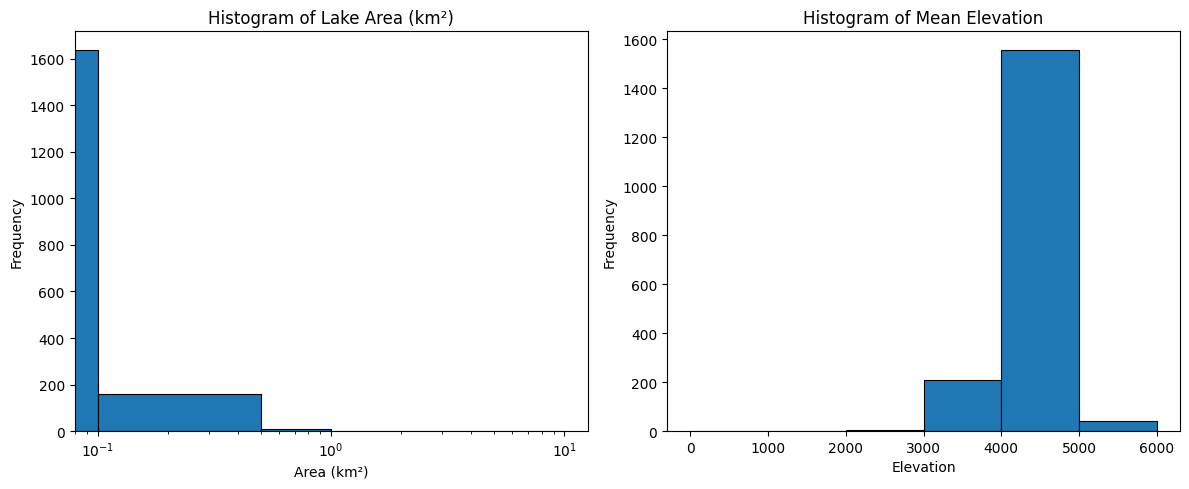

In [28]:
area_bins = [0, 0.1, 0.5, 1, 2, 5, 10]
elev_bins = [0, 1000, 2000, 3000, 4000, 5000, 6000]

plot_area_elevation_histograms(
    gdf_new_stable,
    area_bins=area_bins,
    elev_bins=elev_bins
)